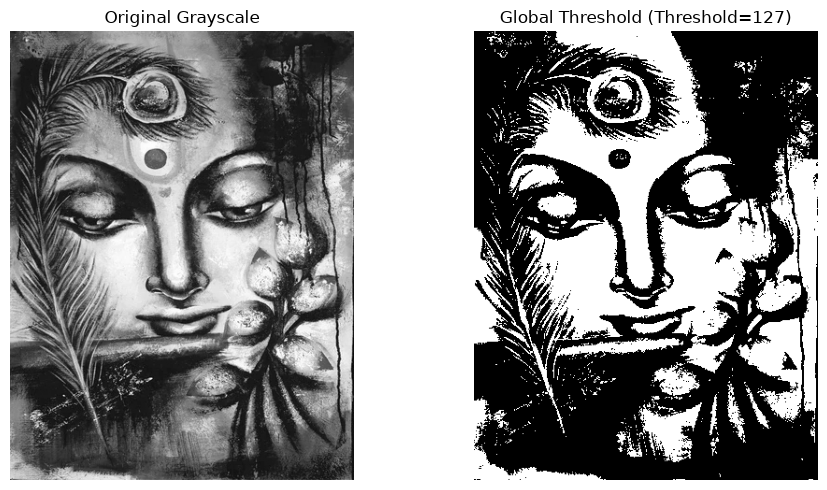

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load YOUR image in grayscale (the '0' flag forces grayscale)
image = cv2.imread("image.webp", 0)

# Quick check to ensure the image loaded correctly
if image is None:
    print("Error: Could not load 'image.webp'. Make sure it is in the exact same folder as this .ipynb file.")
else:
    # 2. Apply Simple Binary Thresholding
    # Parameters: (source_image, threshold_value, max_value, thresholding_type)
    ret, thresh_binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    
    # 3. Display the Original vs Thresholded image side-by-side
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Grayscale")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(thresh_binary, cmap='gray')
    plt.title("Global Threshold (Threshold=127)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

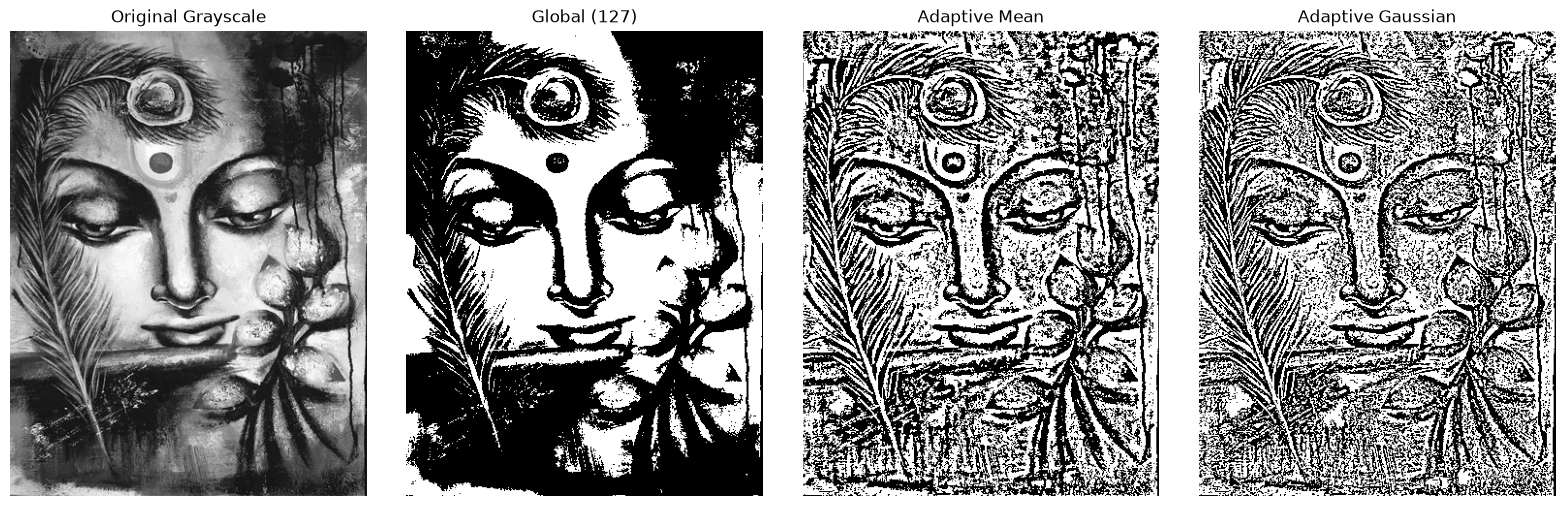

In [2]:
# 1. Adaptive Mean Thresholding
# Calculates the mean of the neighborhood area (11x11 pixels here) minus a constant C (2 here)
thresh_mean = cv2.adaptiveThreshold(
    image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

# 2. Adaptive Gaussian Thresholding
# Calculates the weighted sum of neighborhood values (Gaussian window) minus constant C (2 here)
thresh_gaussian = cv2.adaptiveThreshold(
    image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

# 3. Display the results to compare them
titles = ['Original Grayscale', 'Global (127)', 'Adaptive Mean', 'Adaptive Gaussian']
# Note: We reuse 'thresh_binary' from your previous cell
images = [image, thresh_binary, thresh_mean, thresh_gaussian]

plt.figure(figsize=(16, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()